### Instalação e Importação da Biblioteca

In [1]:
!pip install opencv-python matplotlib numpy

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import cv2

print(cv2)
print(cv2.__file__)
print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

<module 'cv2' from 'C:\\Users\\jones\\AppData\\Local\\Programs\\Python\\Python313\\Lib\\site-packages\\cv2\\__init__.py'>
C:\Users\jones\AppData\Local\Programs\Python\Python313\Lib\site-packages\cv2\__init__.py
4.12.0
True


### Ler Imagem

Lemos a imagem com `cv2.imread` (que carrega em BGR) e convertemos para RGB apenas para exibição com o `matplotlib` (o processamento em si pode ser feito em BGR ou RGB, já que só estamos aplicando blur e detecção — não faz diferença de canal aqui).

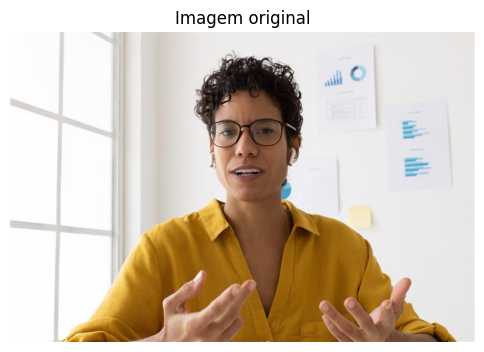

In [14]:
image_bgr = cv2.imread("desafio_1.jpeg")
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6, 6))
plt.imshow(image_rgb)
plt.title("Imagem original")
plt.axis("off")
plt.show()

### Transformar em Escala de Cinza

O `haarcascade` espera uma imagem em tons de cinza para detectar rostos.

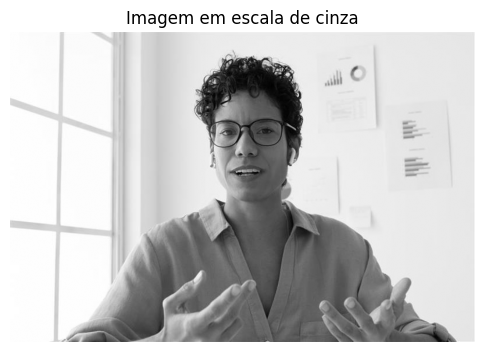

In [15]:
image_gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(6, 6))
plt.imshow(image_gray, cmap="gray")
plt.title("Imagem em escala de cinza")
plt.axis("off")
plt.show()

### Detectar as Faces

1 rosto(s) detectado(s).


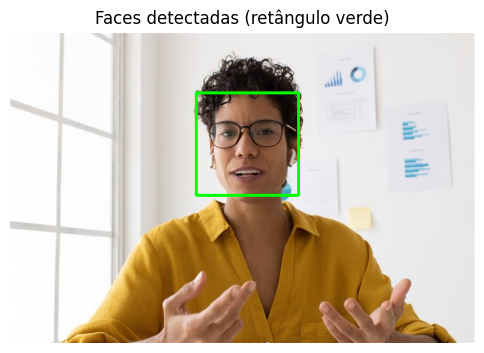

In [16]:
detec = cv2.CascadeClassifier("haarcascade_frontalface_default.xml")
faces = detec.detectMultiScale(image_gray, scaleFactor=1.3, minNeighbors=3)

padding = 40  # pixels de folga ao redor do rosto detectado

altura_img, largura_img = image_rgb.shape[:2]
copy_image_rgb = image_rgb.copy()

faces_com_padding = []  # vai guardar (x1, y1, x2, y2) de cada rosto, já com padding

for (x, y, larg, alt) in faces:
    # Desenha o retângulo original (sem padding) só para visualização
    cv2.rectangle(copy_image_rgb, (x, y), (x + larg, y + alt), (0, 255, 0), 3)

    x1 = max(0, x - padding)
    y1 = max(0, y - padding)
    x2 = min(largura_img, x + larg + padding)
    y2 = min(altura_img, y + alt + padding)

    faces_com_padding.append((x1, y1, x2, y2))

print(f"{len(faces_com_padding)} rosto(s) detectado(s).")

plt.figure(figsize=(6, 6))
plt.imshow(copy_image_rgb)
plt.title("Faces detectadas (retângulo verde)")
plt.axis("off")
plt.show()

### Criar uma Máscara Suave para a Região do Rosto

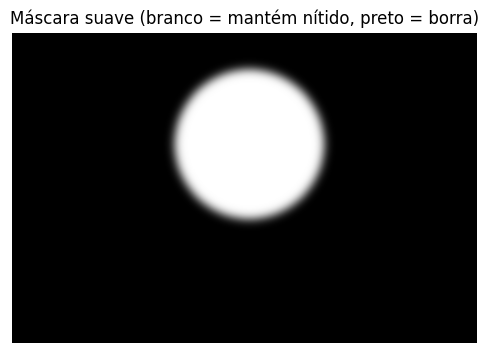

In [17]:
mask = np.zeros((altura_img, largura_img), dtype=np.uint8)

for (x1, y1, x2, y2) in faces_com_padding:
    centro = ((x1 + x2) // 2, (y1 + y2) // 2)
    eixos = ((x2 - x1) // 2, (y2 - y1) // 2)
    cv2.ellipse(mask, centro, eixos, angle=0, startAngle=0, endAngle=360,
                color=255, thickness=-1)  # thickness=-1 preenche a elipse

# Suaviza as bordas da máscara (evita corte abrupto entre nítido e borrado)
mask_suave = cv2.GaussianBlur(mask, (51, 51), 0)

plt.figure(figsize=(6, 6))
plt.imshow(mask_suave, cmap="gray")
plt.title("Máscara suave (branco = mantém nítido, preto = borra)")
plt.axis("off")
plt.show()

### Borrar a Imagem Inteira

Igual ao gabarito, aplicamos `GaussianBlur` na imagem inteira. Aqui usamos um kernel um pouco maior (`(31, 31)`) para deixar o efeito de fundo desfocado mais evidente.

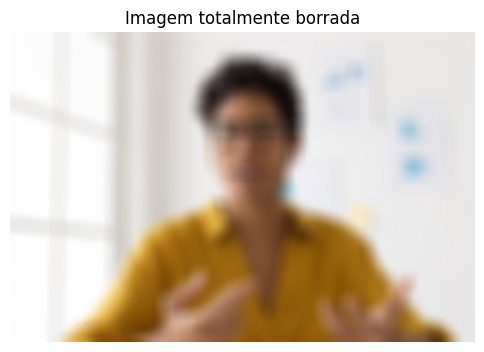

In [18]:
blured_image = cv2.GaussianBlur(image_rgb, (31, 31), 20)

plt.figure(figsize=(6, 6))
plt.imshow(blured_image)
plt.title("Imagem totalmente borrada")
plt.axis("off")
plt.show()

### Compor a Imagem Final Misturando com a Máscara

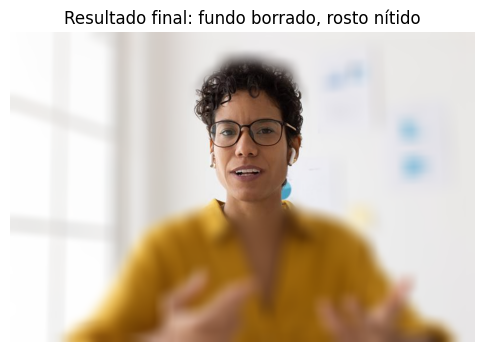

In [19]:
# Normaliza a máscara para valores entre 0 e 1, e replica para os 3 canais (RGB)
alpha = (mask_suave.astype(np.float32) / 255.0)
alpha_3canais = np.repeat(alpha[:, :, np.newaxis], 3, axis=2)

original_float = image_rgb.astype(np.float32)
blur_float = blured_image.astype(np.float32)

final_image = (original_float * alpha_3canais + blur_float * (1 - alpha_3canais))
final_image = np.clip(final_image, 0, 255).astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.imshow(final_image)
plt.title("Resultado final: fundo borrado, rosto nítido")
plt.axis("off")
plt.show()

### Comparação Lado a Lado

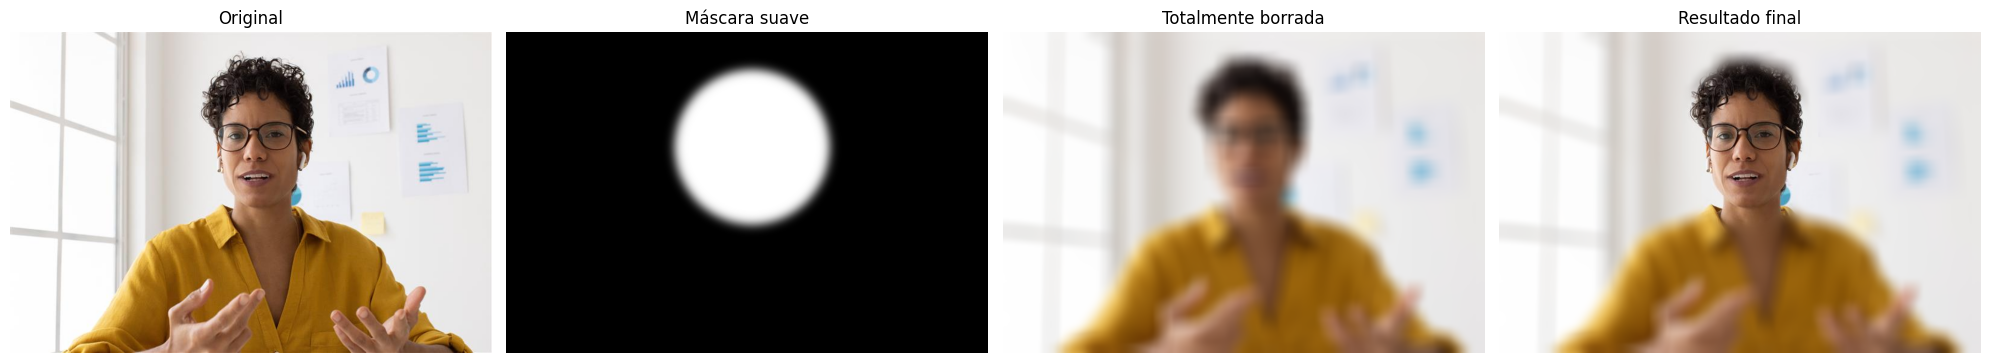

In [20]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

axs[0].imshow(image_rgb)
axs[0].set_title("Original")

axs[1].imshow(mask_suave, cmap="gray")
axs[1].set_title("Máscara suave")

axs[2].imshow(blured_image)
axs[2].set_title("Totalmente borrada")

axs[3].imshow(final_image)
axs[3].set_title("Resultado final")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()